In [1]:
import os
import pandas as pd
from pathlib import Path
import sys

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed" 
PROCESSED_FEATURE_DIR = PROCESSED_DIR / "features"

COMPANIES_DIR = BASE_DIR / "data" / "raw" / "companies"

sys.path.append(str(BASE_DIR))

returns_df = pd.read_parquet(os.path.join(COMPANIES_DIR, "returns.parquet"))

feature_matrix_pipeline_dict = {
    "feature_matrix_stock": os.path.join(PROCESSED_FEATURE_DIR, "feature_matrix_stock.parquet"), 
    "feature_matrix_market": os.path.join(PROCESSED_FEATURE_DIR, "feature_matrix_market.parquet"), 
    "feature_matrix_macro_market": os.path.join(PROCESSED_FEATURE_DIR, "feature_matrix_macro_market.parquet")
}

In [2]:
from scripts.models.lightgbm.tune_lightgbm import LightGBMTuner
from scripts.models.lightgbm.lightgbm_model import LightGBMRegressionModel

from scripts.models.xgboost.tune_xgboost import XGBoostTuner
from scripts.models.xgboost.xgboost_model import XGBoostRegressionModel
from scripts.models.walk_forward import WalkForwardValidator

In [3]:
feature_matrix_stock = pd.read_parquet(feature_matrix_pipeline_dict["feature_matrix_stock"])
feature_matrix_market = pd.read_parquet(feature_matrix_pipeline_dict["feature_matrix_market"])
feature_matrix_macro_market = pd.read_parquet(feature_matrix_pipeline_dict["feature_matrix_macro_market"])

In [4]:
print(feature_matrix_stock)

             Date  Ticker  autocorr_21  autocorr_63  market_beta_63  \
0      2022-06-14  360.AX          NaN          NaN             NaN   
1      2022-06-14  4DX.AX          NaN          NaN             NaN   
2      2022-06-14  A2M.AX          NaN          NaN             NaN   
3      2022-06-14  AAI.AX          NaN          NaN             NaN   
4      2022-06-14  AGL.AX          NaN          NaN             NaN   
...           ...     ...          ...          ...             ...   
202395 2026-06-12  XRO.AX     0.015152        0.080           0.455   
202396 2026-06-12  XYZ.AX     0.671717        0.635           0.560   
202397 2026-06-12  YAL.AX     0.439394        0.925           0.005   
202398 2026-06-12  ZIM.AX     0.868687        0.160           0.625   
202399 2026-06-12  ZIP.AX     0.742424        0.040           0.985   

        industry_beta_63  market_resid_vol_126  industry_resid_vol_126  \
0                    NaN                   NaN                     NaN   

### Company Wide Feature Matrix

In [23]:
XGBoostTuner(20, 42, feature_matrix_stock).run_data()

c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\xgboost\tune_xgboost.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


1/20: IC = 0.01632


c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\xgboost\tune_xgboost.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


2/20: IC = 0.03080


c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\xgboost\tune_xgboost.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


...

c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\xgboost\tune_xgboost.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


18/20: IC = 0.02791


c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\xgboost\tune_xgboost.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


19/20: IC = 0.01429
20/20: IC = 0.02044


c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\xgboost\tune_xgboost.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


In [24]:
import json
with open(os.path.join(BASE_DIR, "results/xgboost_model/best_params.json"), "r") as f:
    best_params = json.load(f)
    
int_params = [
    "max_depth",
    "n_estimators",
    "min_child_weight",
]

for p in int_params:
    best_params[p] = int(best_params[p])

In [25]:
best_params

{'learning_rate': 0.01,
 'max_depth': 3,
 'n_estimators': 500,
 'min_child_weight': 10}

In [28]:
model = XGBoostRegressionModel(params=best_params)

wf = WalkForwardValidator(
    feature_matrix=feature_matrix_stock,
    model=model,
    validation_start="2025-07-01",
    validation_end="2026-12-31",
    rebalance_date=1,
    min_train_size=25000,
)

X_test, test_preds = wf.run_data()

daily_ic = test_preds.groupby("Date").apply(
    lambda x: x["prediction"].corr(
        x["future_return_5d"],
        method="spearman",
    ),
    include_groups = False
)

mean_ic = daily_ic.dropna().mean()

In [29]:
mean_ic

np.float64(0.04539480966151561)

In [ ]:
LightGBMTuner(20, 42, feature_matrix_stock).run_data()

c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\lightgbm\tune_lightgbm.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


1/20: IC = 0.02809


c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\lightgbm\tune_lightgbm.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


2/20: IC = 0.03027


c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\lightgbm\tune_lightgbm.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


...

18/20: IC = 0.01486


c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\lightgbm\tune_lightgbm.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


19/20: IC = 0.02583
20/20: IC = 0.02404


c:\Users\Gordon Li\Desktop\systematic_project\scripts\models\lightgbm\tune_lightgbm.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = preds.groupby("Date").apply(


: 

In [161]:
results_df = pd.read_csv(os.path.join(BASE_DIR, "results/lightgbm_model/random_search.csv"))
results_df.head()

,learning_rate,num_leaves,max_depth,n_estimators,min_child_samples,mean_ic
0,0.02,63,9,100,20,0.032295
1,0.01,31,5,300,100,0.023826
2,0.04,63,9,100,100,0.023400
3,0.02,63,5,200,10,0.023225
4,0.01,31,9,200,20,0.022490


In [162]:
import json
with open(os.path.join(BASE_DIR, "results/lightgbm_model/best_params.json"), "r") as f:
    best_params = json.load(f)

In [163]:
int_params = [
    "num_leaves",
    "max_depth",
    "n_estimators",
    "min_child_samples",
]

for p in int_params:
    best_params[p] = int(best_params[p])

In [177]:
model = LightGBMRegressionModel(params=best_params)

wf = WalkForwardValidator(
    feature_matrix=feature_matrix_market,
    model=model,
    validation_start="2025-07-01",
    validation_end="2026-12-31",
    rebalance_date=1,
    min_train_size=25000,
)

X_test, test_preds = wf.run_data()

daily_ic = test_preds.groupby("Date").apply(
    lambda x: x["prediction"].corr(
        x["future_return_5d"],
        method="spearman",
    )
)

mean_ic = daily_ic.dropna().mean()

In [188]:
X_test

,autocorr_21,autocorr_63,market_beta_63,industry_beta_63,market_resid_vol_126,industry_resid_vol_126,mean_volatility_10,mean_volatility_21,mean_volatility_63,amihud_21,...,market_return_5d,market_return_21d,momentum_63_21,momentum_252_21_y,market_volatility_21d,market_volatility_63d,raw_garch_vol,market_drawdown_21d,market_drawdown_63d,market_drawdown_252d
200800,0.191919,0.465,0.705,0.745,0.969231,0.907692,0.742424,0.742424,0.869347,0.418367,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551
200801,0.873737,0.775,0.980,0.990,1.000000,1.000000,0.702020,0.661616,0.452261,0.663265,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551
200802,0.964646,0.580,0.310,0.565,0.635897,0.389744,0.500000,0.398990,0.814070,0.397959,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551
200803,0.530303,0.765,0.395,0.325,0.758974,0.794872,0.752525,0.570707,0.412060,0.734694,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551
200804,0.929293,0.985,0.110,0.475,0.410256,0.384615,0.242424,0.297980,0.190955,0.326531,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200995,0.030303,0.070,0.430,0.620,0.861538,0.379487,0.843434,0.878788,0.663317,0.142857,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551
200996,0.919192,0.215,0.570,0.780,0.882051,0.574359,0.111111,0.055556,0.020101,0.561224,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551
200997,0.297980,0.885,0.005,0.895,0.815385,0.738462,0.757576,0.585859,0.849246,0.494898,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551
200998,0.878788,0.150,0.740,0.625,0.835897,0.825641,0.272727,0.343434,0.462312,0.964286,...,0.007693,0.003139,-0.041885,0.018181,0.009586,0.010103,0.00889,-0.017312,-0.028323,-0.051551


In [179]:
mean_ic

0.017541027526196136

<AxesSubplot:xlabel='Date'>

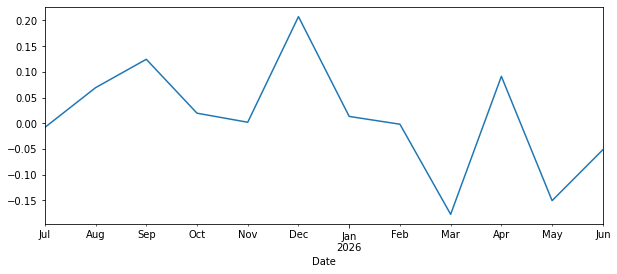

In [180]:
monthly_ic = daily_ic.groupby(daily_ic.index.to_period("M")).mean()
monthly_ic.plot(figsize=(10, 4))

In [181]:
print("Mean IC:", daily_ic.mean())
print("Std IC :", daily_ic.std())
print("ICIR   :", daily_ic.mean() / daily_ic.std())
print("N days :", daily_ic.count())

Mean IC: 0.017541027526196136
Std IC : 0.18702288309498113
ICIR   : 0.09379080910269028
N days : 49


In [168]:
daily_ic_no_june = daily_ic[daily_ic.index < "2026-06-01"]

print("Mean IC:", daily_ic_no_june.mean())
print("Std IC :", daily_ic_no_june.std())
print("ICIR   :", daily_ic_no_june.mean() / daily_ic_no_june.std())
print("N days :", daily_ic_no_june.count())

Mean IC: 0.05299965338483314
Std IC : 0.18892475616855886
ICIR   : 0.28053313107122285
N days : 48


In [185]:
import shap
import numpy as np

explainer = shap.TreeExplainer(model.model)
shap_values = explainer.shap_values(X_test)

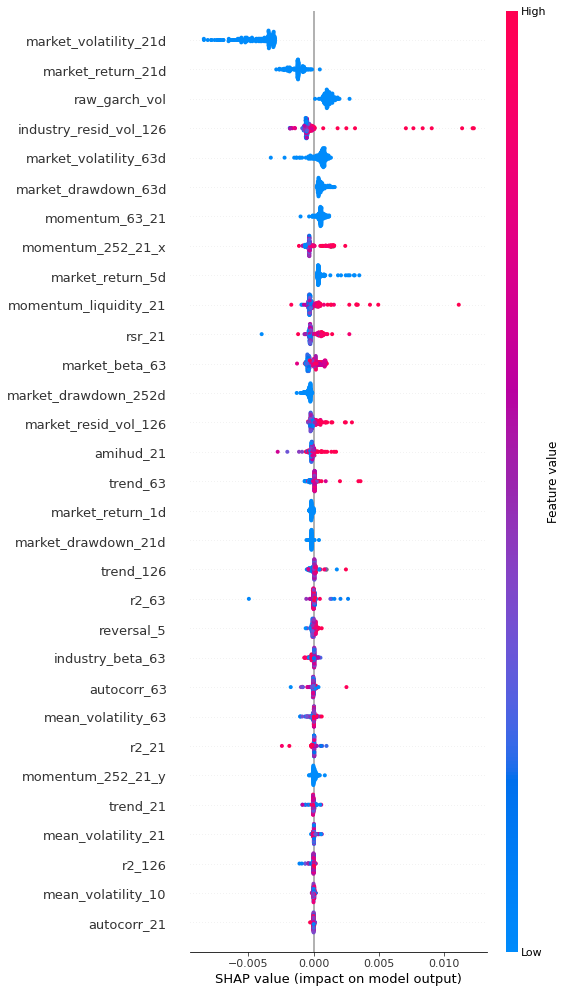

In [186]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=40,
    show=False
)

In [187]:
mean_shap = np.abs(shap_values).mean(axis=0)

importance = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_shap
}).sort_values("mean_abs_shap", ascending=False)

importance.head(40)

,feature,mean_abs_shap
25,market_volatility_21d,0.004235
22,market_return_21d,0.001260
27,raw_garch_vol,0.001115
5,industry_resid_vol_126,0.000840
26,market_volatility_63d,0.000676
29,market_drawdown_63d,0.000573
23,momentum_63_21,0.000570
10,momentum_252_21_x,0.000524
21,market_return_5d,0.000512
11,momentum_liquidity_21,0.000478


In [160]:
LightGBMTuner(20, 42, feature_matrix_market).run_data()

1/20: IC = 0.02249
2/20: IC = 0.01671
3/20: IC = 0.01870
4/20: IC = 0.01123
5/20: IC = 0.03230
6/20: IC = -0.00142
7/20: IC = 0.01079
8/20: IC = 0.02340
9/20: IC = -0.00420
10/20: IC = 0.00152
11/20: IC = 0.02322
12/20: IC = -0.00587
13/20: IC = 0.00578
14/20: IC = -0.00160
15/20: IC = 0.00499
16/20: IC = 0.02383
17/20: IC = -0.00287
18/20: IC = 0.00908
19/20: IC = -0.00085
20/20: IC = -0.00050


In [184]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=40
)

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<AxesSubplot:xlabel='Date', ylabel='future_return_5d'>

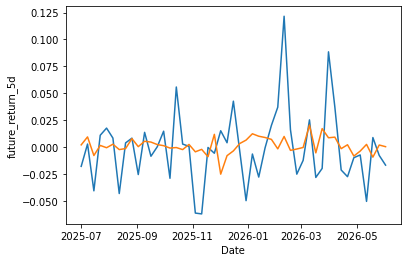

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(test_preds[test_preds["Ticker"] == "CBA.AX"], x= "Date", y="future_return_5d")
sns.lineplot(test_preds[test_preds["Ticker"] == "CBA.AX"], x= "Date", y="prediction")

In [135]:
mean_ic

0.029939570790499002

In [86]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2025-01-07,360.AX,-0.092301,0.007364,LightGBMRegressionModel
1,2025-01-07,4DX.AX,-0.045872,0.011502,LightGBMRegressionModel
2,2025-01-07,A2M.AX,-0.005310,0.004301,LightGBMRegressionModel
3,2025-01-07,AAI.AX,0.004597,0.007716,LightGBMRegressionModel
4,2025-01-07,AGL.AX,0.026786,0.002577,LightGBMRegressionModel
...,...,...,...,...,...
14630,2026-06-02,XRO.AX,-0.117011,0.003038,LightGBMRegressionModel
14631,2026-06-02,XYZ.AX,-0.081132,0.004177,LightGBMRegressionModel
14632,2026-06-02,YAL.AX,-0.075912,0.003503,LightGBMRegressionModel
14633,2026-06-02,ZIM.AX,-0.063725,0.007896,LightGBMRegressionModel


In [132]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2025-01-07,360.AX,-0.092301,0.015119,LightGBMRegressionModel
1,2025-01-07,4DX.AX,-0.045872,0.004043,LightGBMRegressionModel
2,2025-01-07,A2M.AX,-0.005310,-0.003144,LightGBMRegressionModel
3,2025-01-07,AAI.AX,0.004597,0.013069,LightGBMRegressionModel
4,2025-01-07,AGL.AX,0.026786,0.002965,LightGBMRegressionModel
...,...,...,...,...,...
14630,2026-06-02,XRO.AX,-0.117011,0.000476,LightGBMRegressionModel
14631,2026-06-02,XYZ.AX,-0.081132,0.011118,LightGBMRegressionModel
14632,2026-06-02,YAL.AX,-0.075912,0.002419,LightGBMRegressionModel
14633,2026-06-02,ZIM.AX,-0.063725,0.009324,LightGBMRegressionModel


In [62]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2025-01-07,360.AX,-0.092301,0.008235,LightGBMRegressionModel
1,2025-01-07,4DX.AX,-0.045872,0.011259,LightGBMRegressionModel
2,2025-01-07,A2M.AX,-0.005310,0.004833,LightGBMRegressionModel
3,2025-01-07,AAI.AX,0.004597,0.006281,LightGBMRegressionModel
4,2025-01-07,AGL.AX,0.026786,0.000018,LightGBMRegressionModel
...,...,...,...,...,...
14630,2026-06-02,XRO.AX,-0.117011,0.002264,LightGBMRegressionModel
14631,2026-06-02,XYZ.AX,-0.081132,0.003784,LightGBMRegressionModel
14632,2026-06-02,YAL.AX,-0.075912,0.003665,LightGBMRegressionModel
14633,2026-06-02,ZIM.AX,-0.063725,0.005996,LightGBMRegressionModel


In [11]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2026-01-06,360.AX,-0.010645,0.006775,LightGBMRegressionModel
1,2026-01-06,4DX.AX,0.023866,0.040542,LightGBMRegressionModel
2,2026-01-06,A2M.AX,0.016575,0.003937,LightGBMRegressionModel
3,2026-01-06,AAI.AX,0.072621,0.003289,LightGBMRegressionModel
4,2026-01-06,AGL.AX,-0.026316,0.003052,LightGBMRegressionModel
...,...,...,...,...,...
4395,2026-06-02,XRO.AX,-0.117011,0.000539,LightGBMRegressionModel
4396,2026-06-02,XYZ.AX,-0.081132,0.002522,LightGBMRegressionModel
4397,2026-06-02,YAL.AX,-0.075912,0.003860,LightGBMRegressionModel
4398,2026-06-02,ZIM.AX,-0.063725,0.008691,LightGBMRegressionModel


In [14]:
test_preds.tail(20)

,Date,Ticker,future_return_5d,prediction,model_name
14615,2026-06-02,TWE.AX,0.150852,0.003058,LightGBMRegressionModel
14616,2026-06-02,VAU.AX,-0.132420,0.004760,LightGBMRegressionModel
14617,2026-06-02,VCX.AX,0.057851,0.002377,LightGBMRegressionModel
14618,2026-06-02,VEA.AX,0.079439,0.004567,LightGBMRegressionModel
14619,2026-06-02,VGN.AX,0.003788,0.002527,LightGBMRegressionModel
14620,2026-06-02,VNT.AX,0.019048,0.001519,LightGBMRegressionModel
14621,2026-06-02,WAF.AX,-0.118750,0.001105,LightGBMRegressionModel
14622,2026-06-02,WBC.AX,-0.005058,0.002088,LightGBMRegressionModel
14623,2026-06-02,WDS.AX,-0.005447,0.003790,LightGBMRegressionModel
14624,2026-06-02,WES.AX,0.053569,0.001519,LightGBMRegressionModel


<AxesSubplot:xlabel='Date', ylabel='future_return_5d'>

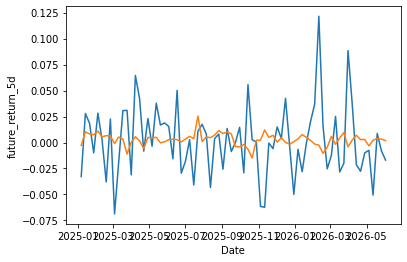

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(test_preds[test_preds["Ticker"] == "CBA.AX"], x= "Date", y="future_return_5d")
sns.lineplot(test_preds[test_preds["Ticker"] == "CBA.AX"], x= "Date", y="prediction")

<AxesSubplot:xlabel='Date', ylabel='future_return_5d'>

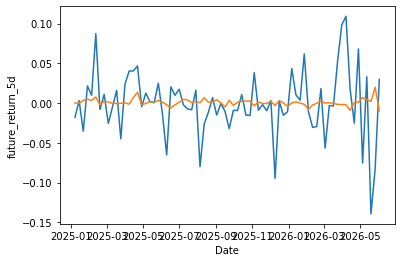

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(test_preds[test_preds["Ticker"] == "ASX.AX"], x= "Date", y="future_return_5d")
sns.lineplot(test_preds[test_preds["Ticker"] == "ASX.AX"], x= "Date", y="prediction")

<AxesSubplot:xlabel='Date'>

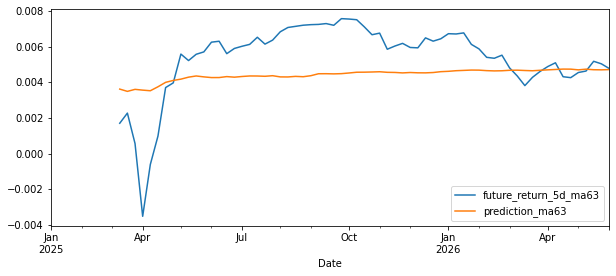

In [139]:
tmp = test_preds.sort_values("Date").copy()

daily_avg = (
    tmp.groupby("Date")[["future_return_5d", "prediction"]]
       .mean()
       .reset_index()
)

daily_avg["future_return_5d_ma63"] = (
    daily_avg["future_return_5d"]
    .rolling(63, min_periods=10)
    .mean()
)

daily_avg["prediction_ma63"] = (
    daily_avg["prediction"]
    .rolling(63, min_periods=10)
    .mean()
)

daily_avg.plot(
    x="Date",
    y=["future_return_5d_ma63", "prediction_ma63"],
    figsize=(10, 4)
)

In [136]:
ticker = "CBA.AX"   # change this

tmp = (
    test_preds[test_preds["Ticker"] == ticker]
    .sort_values("Date")
    .copy()
)

tmp[["future_return_5d", "prediction"]].describe()

,future_return_5d,prediction
count,74.000000,74.000000
mean,0.001555,0.002797
std,0.033303,0.005830
min,-0.068712,-0.014885
25%,-0.019618,0.000192
50%,0.000348,0.003308
75%,0.018741,0.005756
max,0.121519,0.025448


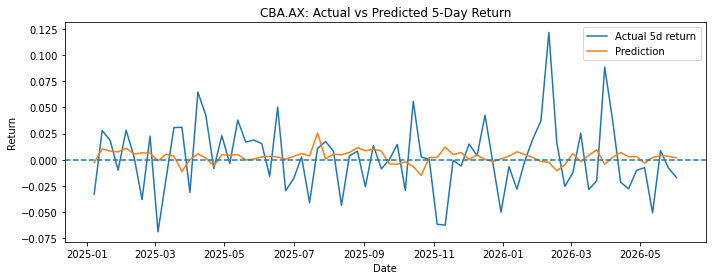

In [137]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(tmp["Date"], tmp["future_return_5d"], label="Actual 5d return")
ax.plot(tmp["Date"], tmp["prediction"], label="Prediction")

ax.axhline(0, linestyle="--")
ax.set_title(f"{ticker}: Actual vs Predicted 5-Day Return")
ax.set_xlabel("Date")
ax.set_ylabel("Return")
ax.legend()

plt.tight_layout()
plt.show()

<AxesSubplot:title={'center':'CBA.AX: Rolling Actual vs Prediction'}, xlabel='Date'>

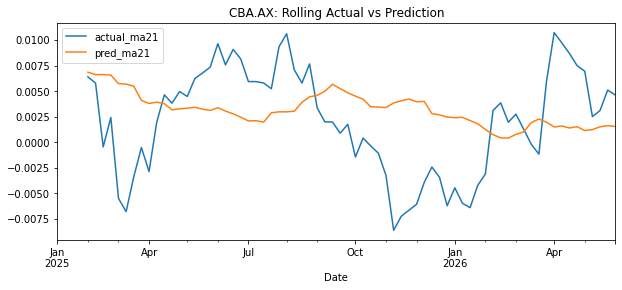

In [138]:
tmp["actual_ma21"] = tmp["future_return_5d"].rolling(21, min_periods=5).mean()
tmp["pred_ma21"] = tmp["prediction"].rolling(21, min_periods=5).mean()

tmp.plot(
    x="Date",
    y=["actual_ma21", "pred_ma21"],
    figsize=(10, 4),
    title=f"{ticker}: Rolling Actual vs Prediction"
)

In [18]:
test_preds[test_preds["Ticker"] == "CBA.AX"].tail(20)

,Date,Ticker,future_return_5d,prediction,model_name
10671,2026-01-20,CBA.AX,-0.000797,0.005862,LightGBMRegressionModel
10871,2026-01-27,CBA.AX,0.020057,0.005613,LightGBMRegressionModel
11071,2026-02-03,CBA.AX,0.036974,-0.000814,LightGBMRegressionModel
11271,2026-02-10,CBA.AX,0.121519,0.007514,LightGBMRegressionModel
11471,2026-02-17,CBA.AX,0.016052,-0.003701,LightGBMRegressionModel
11671,2026-02-24,CBA.AX,-0.025322,-0.002381,LightGBMRegressionModel
11871,2026-03-03,CBA.AX,-0.012530,-0.003861,LightGBMRegressionModel
12071,2026-03-10,CBA.AX,0.025145,0.020334,LightGBMRegressionModel
12271,2026-03-17,CBA.AX,-0.028390,-0.000389,LightGBMRegressionModel
12471,2026-03-24,CBA.AX,-0.019986,0.014370,LightGBMRegressionModel


In [10]:
mean_ic

0.021802123919010756

In [88]:
import shap
import numpy as np

explainer = shap.TreeExplainer(model.model)
shap_values = explainer.shap_values(X_test)

In [89]:
shap_importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

In [90]:
shap_importance

,feature,mean_abs_shap
0,market_volatility_21d,0.001665
1,raw_garch_vol,0.001411
2,momentum_63_21,0.000702
3,industry_resid_vol_126,0.000639
4,market_resid_vol_126,0.000480
5,momentum_liquidity_21,0.000473
6,market_return_21d,0.000462
7,momentum_252_21_x,0.000421
8,market_beta_63,0.000375
9,market_drawdown_63d,0.000324


In [93]:
feature_matrix_subset = feature_matrix_market[["Date", "Ticker"] + shap_importance["feature"].tolist()[:10] + ["future_return_5d"]]

In [94]:
LightGBMTuner(20, 42, feature_matrix_subset).run_data()

1/20: IC = 0.00332
2/20: IC = 0.00304
3/20: IC = 0.00251
4/20: IC = 0.00109
5/20: IC = 0.00648
6/20: IC = 0.00095
7/20: IC = -0.00768
8/20: IC = 0.00571
9/20: IC = 0.00817
10/20: IC = 0.00012
11/20: IC = -0.00617
12/20: IC = 0.00000
13/20: IC = -0.00156
14/20: IC = 0.00588
15/20: IC = -0.00679
16/20: IC = 0.00681
17/20: IC = -0.00957
18/20: IC = -0.00039
19/20: IC = 0.00618
20/20: IC = -0.01091


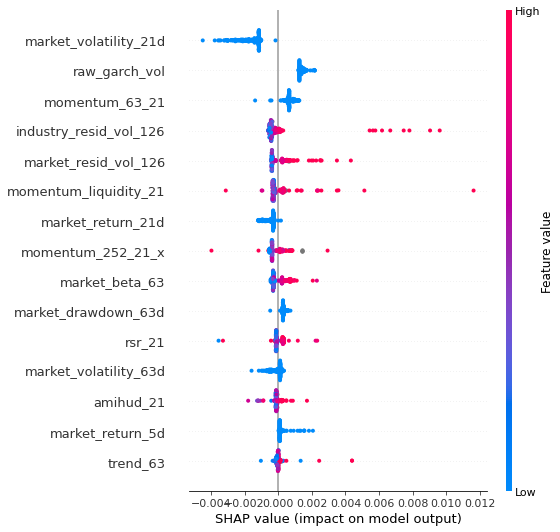

In [92]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=40
)

In [9]:
test_preds

,Date,Ticker,future_return_5d,prediction,model_name
0,2025-01-07,360.AX,-0.092301,0.008161,LightGBMRegressionModel
1,2025-01-07,4DX.AX,-0.045872,0.013369,LightGBMRegressionModel
2,2025-01-07,A2M.AX,-0.005310,0.005259,LightGBMRegressionModel
3,2025-01-07,AAI.AX,0.004597,0.005871,LightGBMRegressionModel
4,2025-01-07,AGL.AX,0.026786,0.000057,LightGBMRegressionModel
...,...,...,...,...,...
14630,2026-06-02,XRO.AX,-0.117011,0.001098,LightGBMRegressionModel
14631,2026-06-02,XYZ.AX,-0.081132,0.003740,LightGBMRegressionModel
14632,2026-06-02,YAL.AX,-0.075912,0.004971,LightGBMRegressionModel
14633,2026-06-02,ZIM.AX,-0.063725,0.007394,LightGBMRegressionModel


In [17]:
daily_ic.describe()

count    22.000000
mean      0.014099
std       0.264017
min      -0.469219
25%      -0.210645
50%       0.086294
75%       0.228590
max       0.393173
dtype: float64

In [20]:
0.014099/0.264


0.05340530303030303

In [14]:
positive_rate = (daily_ic > 0).mean()
print(positive_rate)

0.5909090909090909


In [15]:
bad_dates = daily_ic.sort_values().head(10).index

bad_preds = test_preds[test_preds["Date"].isin(bad_dates)].copy()

bad_summary = (
    bad_preds
    .groupby("Date")
    .agg(
        n_stocks=("Ticker", "count"),
        avg_target=("future_return_5d", "mean"),
        avg_prediction=("prediction", "mean"),
        std_target=("future_return_5d", "std"),
        std_prediction=("prediction", "std"),
    )
)

bad_summary

,n_stocks,avg_target,avg_prediction,std_target,std_prediction
Date,,,,,
2026-01-27,200,-0.029270,0.005065,0.051012,0.003680
2026-02-10,200,-0.021499,0.004554,0.058507,0.003547
2026-03-03,200,-0.038040,0.005076,0.062863,0.005247
2026-03-10,200,-0.023105,0.004555,0.059439,0.004869
2026-03-17,200,-0.029865,0.004303,0.069397,0.004738
2026-04-21,200,-0.029337,0.004164,0.055700,0.004296
2026-04-28,200,-0.001567,0.004105,0.047251,0.004295
2026-05-12,200,-0.008394,0.003979,0.069335,0.005043
2026-05-26,200,0.011444,0.003755,0.058224,0.004852


In [16]:
test_preds["prediction"].describe()

count    4400.000000
mean        0.004343
std         0.004352
min        -0.013644
25%         0.002304
50%         0.003073
75%         0.004953
max         0.049389
Name: prediction, dtype: float64

In [17]:
date = test_preds["Date"].iloc[0]

tmp = test_preds[test_preds["Date"] == date]

print(tmp["prediction"].describe())
print(tmp["future_return_5d"].describe())

count    200.000000
mean       0.004826
std        0.004869
min       -0.004225
25%        0.002722
50%        0.003496
75%        0.005118
max        0.043668
Name: prediction, dtype: float64
count    200.000000
mean       0.021588
std        0.043674
min       -0.070822
25%       -0.000645
50%        0.014969
75%        0.036197
max        0.258932
Name: future_return_5d, dtype: float64


In [18]:
date = test_preds["Date"].iloc[0]

tmp = test_preds[test_preds["Date"] == date].copy()

tmp[["prediction", "future_return_5d"]].corr(method="spearman")

,prediction,future_return_5d
prediction,1.000000,0.139225
future_return_5d,0.139225,1.000000


In [25]:
bad_date = "2026-06-02"

tmp = test_preds[test_preds["Date"] == bad_date].copy()

tmp.sort_values("prediction", ascending=False)[
    ["Ticker", "prediction", "future_return_5d"]
].head(20)

tmp.sort_values("prediction", ascending=True)[
    ["Ticker", "prediction", "future_return_5d"]
].head(20)

,Ticker,prediction,future_return_5d
4201,4DX.AX,-0.010669,-0.051948
4260,DRO.AX,-0.004666,-0.137072
4295,LLC.AX,0.002244,-0.026022
4248,CPU.AX,0.002244,0.038704
4268,EVT.AX,0.002244,0.052233
4370,SUN.AX,0.002244,0.062209
4209,ALL.AX,0.002244,0.037517
4310,MTS.AX,0.002244,0.043189
4303,MGR.AX,0.002244,0.052308
4355,SDF.AX,0.002244,0.341646


In [26]:
best_params

{'learning_rate': 0.01,
 'num_leaves': 15,
 'max_depth': 7,
 'n_estimators': 100,
 'min_child_samples': 100}

In [13]:
directional_accuracy = (
    (output_test["prediction"] > 0)
    ==
    (output_test["future_return_5d"] > 0)
).mean()

In [14]:
directional_accuracy

0.5171389109781107

Text(0, 0.5, 'Future Return 5D')

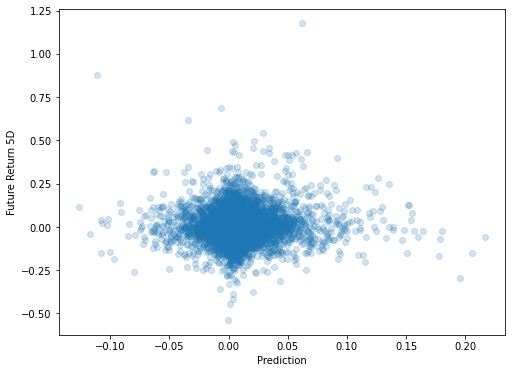

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    output_test["prediction"],
    output_test["future_return_5d"],
    alpha=0.2
)
plt.xlabel("Prediction")
plt.ylabel("Future Return 5D")

In [12]:
output_test["decile"] = pd.qcut(
    output_test["prediction"],
    10,
    labels=False,
    duplicates="drop"
)

output_test.groupby("decile")["future_return_5d"].mean()

decile
0    0.005893
1    0.003140
2    0.001767
3    0.001249
4    0.002874
5    0.003179
6    0.004238
7    0.004239
8    0.003262
9    0.013276
Name: future_return_5d, dtype: float64

In [7]:
output_test["future_return_5d"].corr(output_test["prediction"])

0.0303088088203395

In [8]:
daily_ic = (
    output_test
    .groupby("Date")
    .apply(lambda x: x["prediction"].corr(x["future_return_5d"]))
)

In [9]:
print(daily_ic.mean())
print(daily_ic.std())
print((daily_ic > 0).mean())

0.03964415067954155
0.16001704697145608
0.5737704918032787


In [ ]:
sns.scatterplot(data=output_test, x=)